# 🎵 Spotify Machine Learning Project
---
### **Objective:** Applying classification and clustering algorithms to analyze music features and predict track patterns.

### **🚀 Implementation Steps:**
* **Algorithms:** KNN, K-Means, and Naive Bayes.
* **Task:** Multi-model analysis for classification and grouping.
* **Evaluation:** Performance check using Confusion Matrix and Regression metrics ($MSE, MAE, RMSE, R^2$).

**Prepared by:** Hala & Abdallah

#**Step 1: Data Loading & Library Setup**
In this initial step, we import the essential Python libraries for data manipulation and machine learning. We also load the Spotify 2023 dataset using the appropriate encoding to ensure all character data is correctly read.

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. Load the dataset
# Make sure 'spotify-2023.csv' is uploaded to your Colab environment
df = pd.read_csv('spotify-2023.csv', encoding='latin-1')


#**Step 2: Data Cleaning & Preprocessing**
In this step, we handle data inconsistencies by converting the 'streams' column to a numeric format and removing any invalid entries. We also address missing values in the 'key' and 'shazam charts' columns to ensure our dataset is complete and ready for analysis.

In [ ]:
# 2. Data Cleaning
# Convert 'streams' to numeric, forcing errors to NaN then dropping them
df['streams'] = pd.to_numeric(df['streams'], errors='coerce')
df = df.dropna(subset=['streams'])
# Filling missing values in 'key' with 'Unknown' and 'in_shazam_charts' with 0
df['key'] = df['key'].fillna('Unknown')
df['in_shazam_charts'] = df['in_shazam_charts'].fillna(0)



#**Step 3: Feature Selection (Audio Features)**
In this step, we isolate the specific numerical attributes that define the musical characteristics of each track. These features—such as BPM, danceability, and energy—will be the primary inputs for our machine learning models to identify patterns and similarities

In [ ]:
# 3. Feature Selection (Audio Features)
features_list = [
    'bpm', 'danceability_%', 'valence_%', 'energy_%',
    'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%'
]
X = df[features_list]


In [ ]:
# 4. Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Summary Output
print("Dataset loaded successfully!")
print(f"Shape of features: {X_scaled.shape}")
print(df.info())

Dataset loaded successfully!
Shape of features: (952, 8)
<class 'pandas.core.frame.DataFrame'>
Index: 952 entries, 0 to 952
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   track_name            952 non-null    object 
 1   artist(s)_name        952 non-null    object 
 2   artist_count          952 non-null    int64  
 3   released_year         952 non-null    int64  
 4   released_month        952 non-null    int64  
 5   released_day          952 non-null    int64  
 6   in_spotify_playlists  952 non-null    int64  
 7   in_spotify_charts     952 non-null    int64  
 8   streams               952 non-null    float64
 9   in_apple_playlists    952 non-null    int64  
 10  in_apple_charts       952 non-null    int64  
 11  in_deezer_playlists   952 non-null    object 
 12  in_deezer_charts      952 non-null    int64  
 13  in_shazam_charts      952 non-null    object 
 14  bpm                   

## 6. Exploratory Data Analysis (EDA)

Before proceeding with further analysis, let's ensure all relevant columns are in the correct data types and explore the distribution of some key categorical features.

In [ ]:
# Convert 'in_deezer_playlists' to numeric, coercing errors
df['in_deezer_playlists'] = pd.to_numeric(df['in_deezer_playlists'], errors='coerce')

# Convert 'in_shazam_charts' to numeric, coercing errors
df['in_shazam_charts'] = pd.to_numeric(df['in_shazam_charts'], errors='coerce')

# Fill any NaNs created by coercion in 'in_deezer_playlists' or 'in_shazam_charts' with 0
df['in_deezer_playlists'] = df['in_deezer_playlists'].fillna(0)
df['in_shazam_charts'] = df['in_shazam_charts'].fillna(0)

print("Value counts for 'key' column:")
print(df['key'].value_counts())
print("\nValue counts for 'mode' column:")
print(df['mode'].value_counts())

Value counts for 'key' column:
key
C#         120
G           96
Unknown     95
G#          91
F           89
B           81
D           81
A           74
F#          73
E           62
A#          57
D#          33
Name: count, dtype: int64

Value counts for 'mode' column:
mode
Major    549
Minor    403
Name: count, dtype: int64


### Distribution of Audio Features

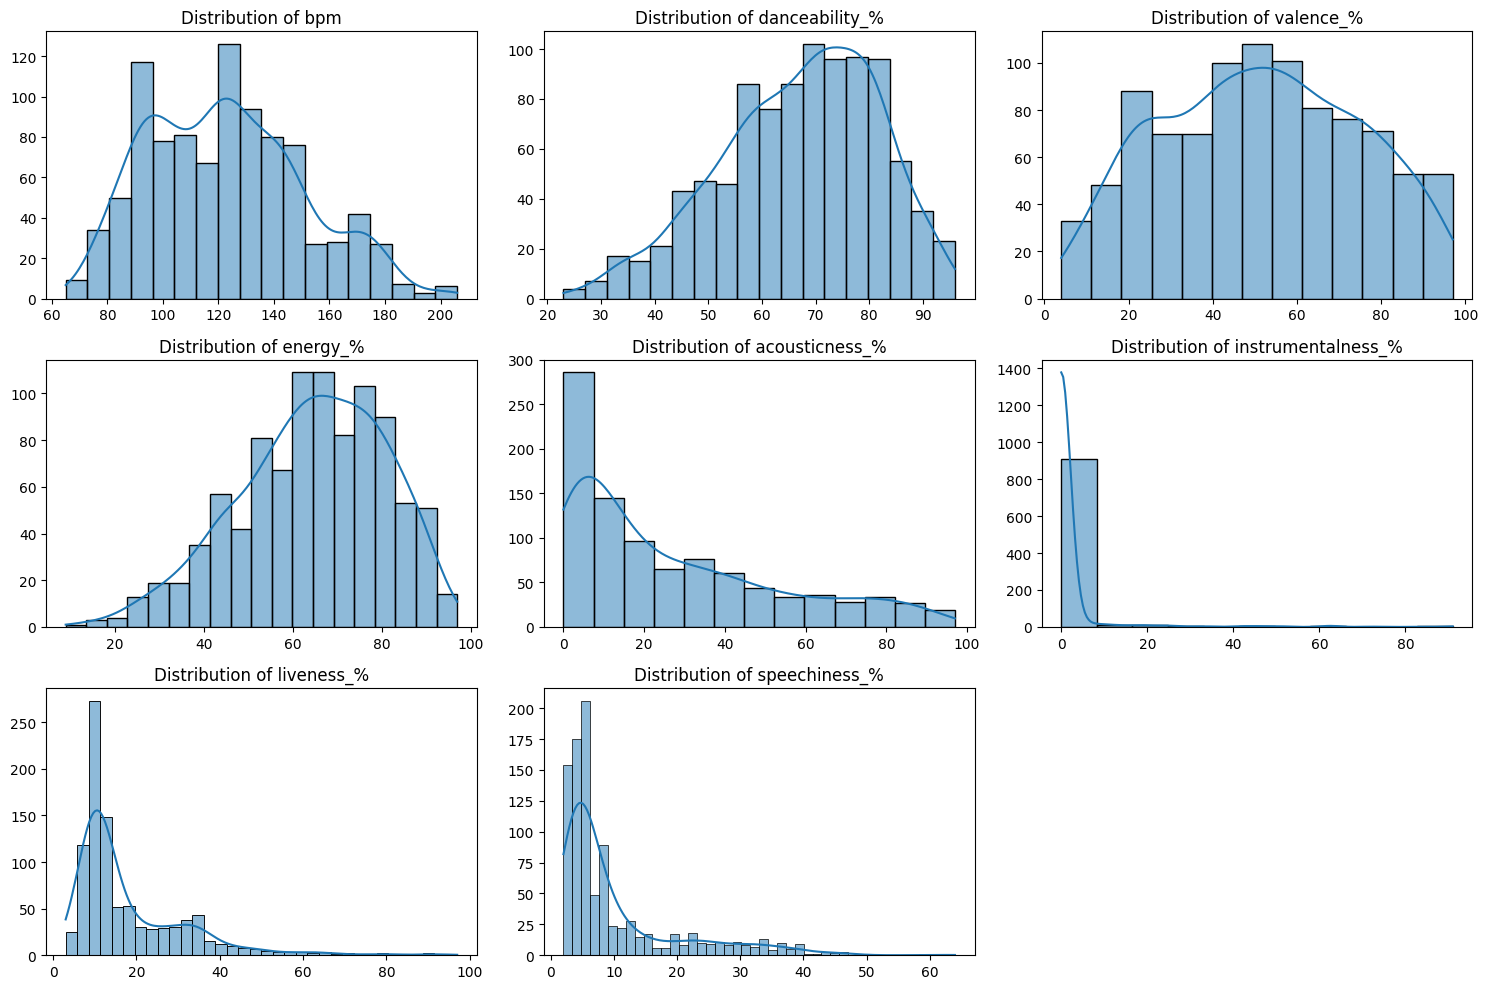

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the matplotlib figure
plt.figure(figsize=(15, 10))

for i, feature in enumerate(features_list):
    plt.subplot(3, 3, i + 1)  # Create a 3x3 grid of subplots
    sns.histplot(df[feature], kde=True)  # Plot histogram with KDE
    plt.title(f'Distribution of {feature}')
    plt.xlabel('')  # Remove x-label to avoid clutter
    plt.ylabel('')  # Remove y-label to avoid clutter

plt.tight_layout()  # Adjust layout to prevent overlapping titles
plt.show()
